# 05 - Classification Models: Predicting AQI Category

Classifying AQI into 6 CPCB categories:
Good | Satisfactory | Moderate | Poor | Very Poor | Severe

Using SMOTE for class imbalance handling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import sys, os
import joblib

sys.path.insert(0, os.path.abspath('..'))
from config import DATA_PROCESSED, FIGURES_DIR, MODELS_DIR, RANDOM_STATE, AQI_CATEGORIES
from src.evaluation.metrics import classification_metrics, print_classification_comparison

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs(MODELS_DIR / 'classification', exist_ok=True)

## 1. Load Data & Encode Target

In [2]:
df_train = pd.read_parquet(DATA_PROCESSED / 'train.parquet')
df_val = pd.read_parquet(DATA_PROCESSED / 'val.parquet')
df_test = pd.read_parquet(DATA_PROCESSED / 'test.parquet')

# Encode AQI_Bucket as ordinal
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
label_map = {b: i for i, b in enumerate(bucket_order)}

for df in [df_train, df_val, df_test]:
    df['AQI_Label'] = df['AQI_Bucket'].map(label_map)

# Feature columns
exclude_cols = ['City', 'Date', 'AQI', 'AQI_Bucket', 'AQI_Label', 'season',
                'AQI_Calculated', 'AQI_Bucket_Calculated', 'Dominant_Pollutant']
feature_cols = [c for c in df_train.columns if c not in exclude_cols]

X_train = np.nan_to_num(df_train[feature_cols].values, nan=0.0)
y_train = df_train['AQI_Label'].values
X_val = np.nan_to_num(df_val[feature_cols].values, nan=0.0)
y_val = df_val['AQI_Label'].values
X_test = np.nan_to_num(df_test[feature_cols].values, nan=0.0)
y_test = df_test['AQI_Label'].values

print(f"Features: {len(feature_cols)}")
print(f"\nClass distribution (train):")
for label, name in enumerate(bucket_order):
    count = (y_train == label).sum()
    print(f"  {name}: {count} ({count/len(y_train)*100:.1f}%)")

Features: 141

Class distribution (train):
  Good: 553 (3.3%)
  Satisfactory: 4918 (29.2%)
  Moderate: 6245 (37.1%)
  Poor: 2114 (12.5%)
  Very Poor: 1884 (11.2%)
  Severe: 1135 (6.7%)


## 2. Apply SMOTE for Class Balancing

In [3]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]} samples")
print(f"After SMOTE:  {X_train_smote.shape[0]} samples")
print(f"\nClass distribution after SMOTE:")
for label, name in enumerate(bucket_order):
    count = (y_train_smote == label).sum()
    print(f"  {name}: {count}")

Before SMOTE: 16849 samples
After SMOTE:  37470 samples

Class distribution after SMOTE:
  Good: 6245
  Satisfactory: 6245
  Moderate: 6245
  Poor: 6245
  Very Poor: 6245
  Severe: 6245


## 3. Train Classification Models

In [4]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1),
        'use_smote': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=15, min_samples_split=10,
                                         random_state=RANDOM_STATE),
        'use_smote': True
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, max_depth=20,
                                         min_samples_split=5, n_jobs=-1,
                                         random_state=RANDOM_STATE),
        'use_smote': True
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=RANDOM_STATE, n_jobs=-1,
                                early_stopping_rounds=50, eval_metric='mlogloss'),
        'use_smote': True,
        'eval_set': True
    },
    'LightGBM': {
        'model': LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05,
                                 min_child_samples=20, subsample=0.8,
                                 colsample_bytree=0.8, random_state=RANDOM_STATE,
                                 n_jobs=-1, verbosity=-1),
        'use_smote': True,
        'eval_set': True
    },
    'CatBoost': {
        'model': CatBoostClassifier(iterations=500, depth=8, learning_rate=0.05,
                                      l2_leaf_reg=3, random_seed=RANDOM_STATE,
                                      verbose=0),
        'use_smote': True,
        'eval_set': True
    },
    'CatBoost (class_weights)': {
        'model': CatBoostClassifier(iterations=500, depth=8, learning_rate=0.05,
                                      l2_leaf_reg=3, random_seed=RANDOM_STATE,
                                      verbose=0, auto_class_weights='Balanced'),
        'use_smote': False,
        'eval_set': True
    },
}

results = {}
cls_predictions = {}

for name, config in models.items():
    print(f"\nTraining {name}...")
    model = config['model']
    use_smote = config.get('use_smote', True)
    use_eval = config.get('eval_set', False)
    
    X_tr = X_train_smote if use_smote else X_train
    y_tr = y_train_smote if use_smote else y_train
    
    start = time.time()
    
    if use_eval and 'XGBoost' in name:
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    elif use_eval and 'LightGBM' in name:
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    elif use_eval and 'CatBoost' in name:
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50)
    else:
        model.fit(X_tr, y_tr)
    
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    cls_predictions[name] = y_pred
    
    metrics = classification_metrics(y_test, y_pred)
    metrics['Train_Time_s'] = round(elapsed, 2)
    results[name] = metrics
    
    print(f"  Accuracy={metrics['Accuracy']:.4f}, Macro_F1={metrics['Macro_F1']:.4f}, "
          f"Kappa={metrics['Cohen_Kappa']:.4f}, Time={elapsed:.1f}s")
    
    joblib.dump(model, MODELS_DIR / 'classification' / f'{name.lower().replace(" ", "_").replace("(","").replace(")","")}.joblib')

print("\nAll classifiers trained and saved.")


Training Logistic Regression...


  Accuracy=0.6965, Macro_F1=0.6416, Kappa=0.5485, Time=26.6s

Training Decision Tree...


  Accuracy=0.7150, Macro_F1=0.6807, Kappa=0.5694, Time=4.6s

Training Random Forest...


  Accuracy=0.7701, Macro_F1=0.7430, Kappa=0.6390, Time=11.4s



Training XGBoost...


  Accuracy=0.8410, Macro_F1=0.8078, Kappa=0.7544, Time=28.0s

Training LightGBM...


  Accuracy=0.8283, Macro_F1=0.8106, Kappa=0.7306, Time=42.6s

Training CatBoost...


  Accuracy=0.8313, Macro_F1=0.8121, Kappa=0.7398, Time=126.2s

Training CatBoost (class_weights)...


  Accuracy=0.8059, Macro_F1=0.7822, Kappa=0.7053, Time=78.1s

All classifiers trained and saved.


## 4. Model Comparison

In [5]:
print("=" * 80)
print("CLASSIFICATION MODEL COMPARISON (Test Set)")
print("=" * 80)
cls_results_df = print_classification_comparison(results)
cls_results_df

CLASSIFICATION MODEL COMPARISON (Test Set)


                          Accuracy  Balanced_Accuracy  Macro_F1  Weighted_F1  Cohen_Kappa  Train_Time_s
XGBoost                     0.8410             0.8039    0.8078       0.8404       0.7544         27.99
CatBoost                    0.8313             0.8039    0.8121       0.8307       0.7398        126.24
LightGBM                    0.8283             0.7868    0.8106       0.8258       0.7306         42.55
CatBoost (class_weights)    0.8059             0.7913    0.7822       0.8059       0.7053         78.05
Random Forest               0.7701             0.7447    0.7430       0.7656       0.6390         11.37
Decision Tree               0.7150             0.7165    0.6807       0.7161       0.5694          4.61
Logistic Regression         0.6965             0.7126    0.6416       0.7011       0.5485         26.65


,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Cohen_Kappa,Train_Time_s
XGBoost,0.841041,0.803859,0.807837,0.840350,0.754383,27.99
CatBoost,0.831349,0.803928,0.812110,0.830703,0.739751,126.24
LightGBM,0.828302,0.786830,0.810595,0.825770,0.730575,42.55
CatBoost (class_weights),0.805871,0.791299,0.782194,0.805878,0.705336,78.05
Random Forest,0.770147,0.744731,0.743035,0.765637,0.638998,11.37
Decision Tree,0.715037,0.716544,0.680663,0.716145,0.569361,4.61
Logistic Regression,0.696483,0.712603,0.641622,0.701115,0.548510,26.65


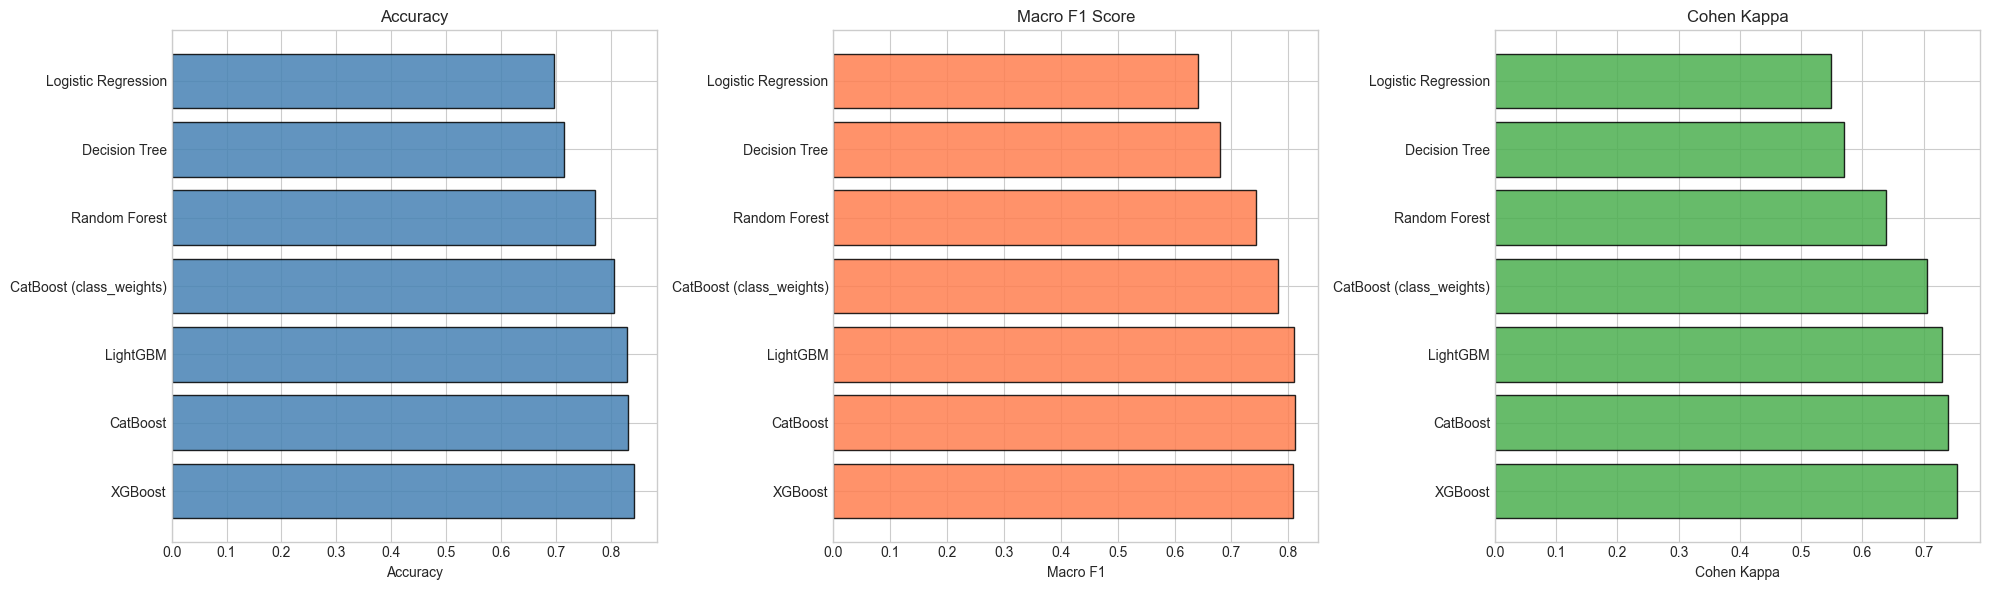

In [6]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_models = cls_results_df.index.tolist()

axes[0].barh(sorted_models, cls_results_df['Accuracy'], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy')

axes[1].barh(sorted_models, cls_results_df['Macro_F1'], color='coral', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Macro F1')
axes[1].set_title('Macro F1 Score')

axes[2].barh(sorted_models, cls_results_df['Cohen_Kappa'], color='#4CAF50', edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Cohen Kappa')
axes[2].set_title('Cohen Kappa')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '19_classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrices (Top 3 Models)

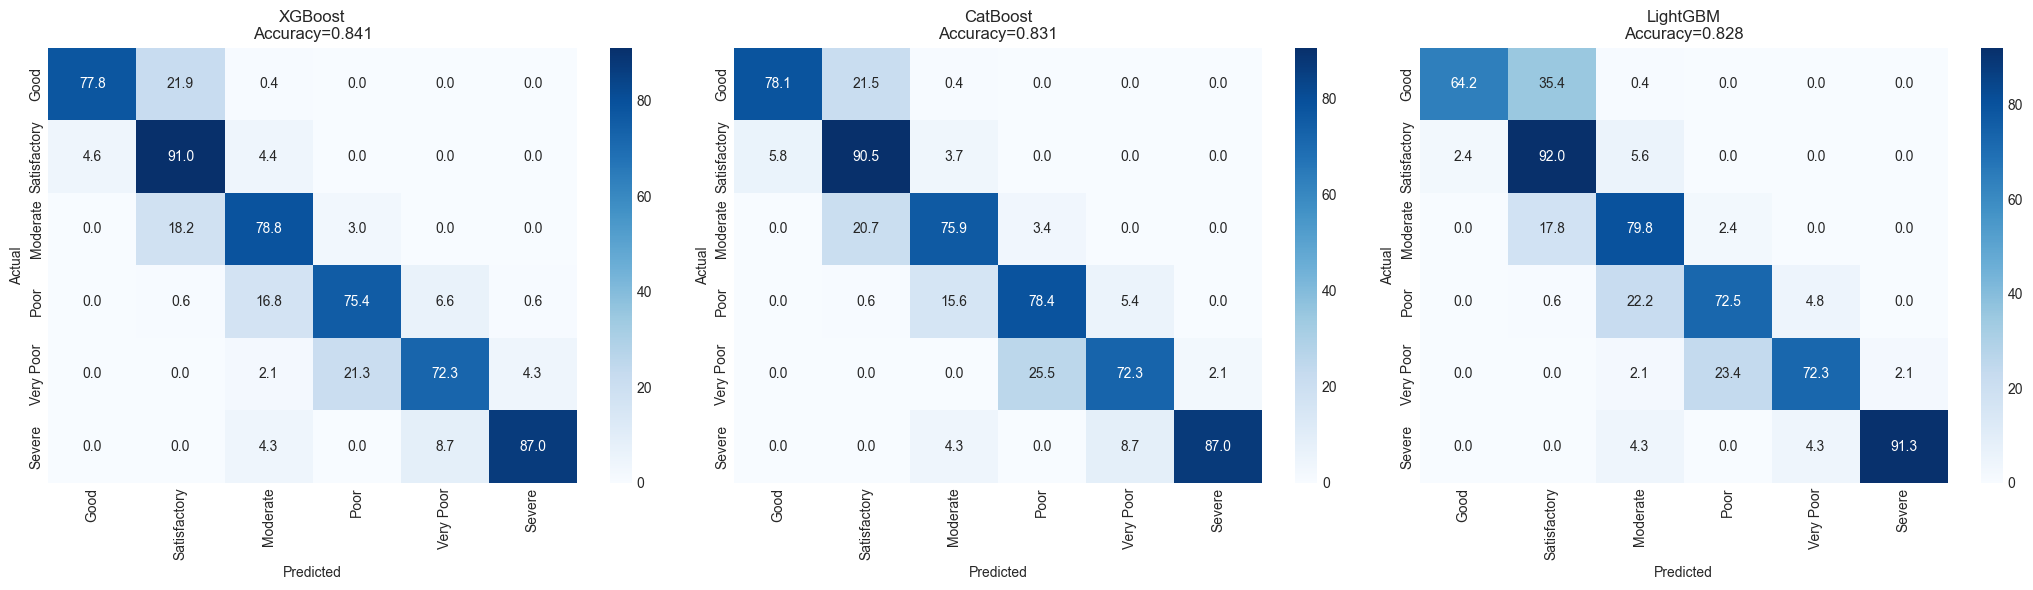

In [7]:
top3 = cls_results_df.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, name in enumerate(top3):
    cm = confusion_matrix(y_test, cls_predictions[name])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[i],
                xticklabels=bucket_order, yticklabels=bucket_order)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{name}\nAccuracy={results[name]["Accuracy"]:.3f}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-Class Performance (Best Model)

In [8]:
best_cls_name = cls_results_df.index[0]
print(f"\nDetailed Classification Report: {best_cls_name}")
print("=" * 60)
print(classification_report(y_test, cls_predictions[best_cls_name],
                             target_names=bucket_order))


Detailed Classification Report: XGBoost
              precision    recall  f1-score   support

        Good       0.84      0.78      0.81       517
Satisfactory       0.82      0.91      0.86      1668
    Moderate       0.90      0.79      0.84      1189
        Poor       0.73      0.75      0.74       167
   Very Poor       0.72      0.72      0.72        47
      Severe       0.87      0.87      0.87        23

    accuracy                           0.84      3611
   macro avg       0.81      0.80      0.81      3611
weighted avg       0.84      0.84      0.84      3611



In [9]:
# Save results
cls_results_df.to_csv(DATA_PROCESSED / 'classification_results.csv')
print("Classification results saved.")

print(f"\nBest Classifier: {best_cls_name}")
print(f"  Accuracy:          {cls_results_df.iloc[0]['Accuracy']:.4f}")
print(f"  Balanced Accuracy: {cls_results_df.iloc[0]['Balanced_Accuracy']:.4f}")
print(f"  Macro F1:          {cls_results_df.iloc[0]['Macro_F1']:.4f}")
print(f"  Cohen Kappa:       {cls_results_df.iloc[0]['Cohen_Kappa']:.4f}")

Classification results saved.

Best Classifier: XGBoost
  Accuracy:          0.8410
  Balanced Accuracy: 0.8039
  Macro F1:          0.8078
  Cohen Kappa:       0.7544
